# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Shape of x_train: (50000, 32, 32, 3)
Shape of y_train: (50000, 1)
Shape of x_test: (10000, 32, 32, 3)
Shape of y_test: (10000, 1)
Image dimensions: 32 x 32 pixels
Number of classes: 100


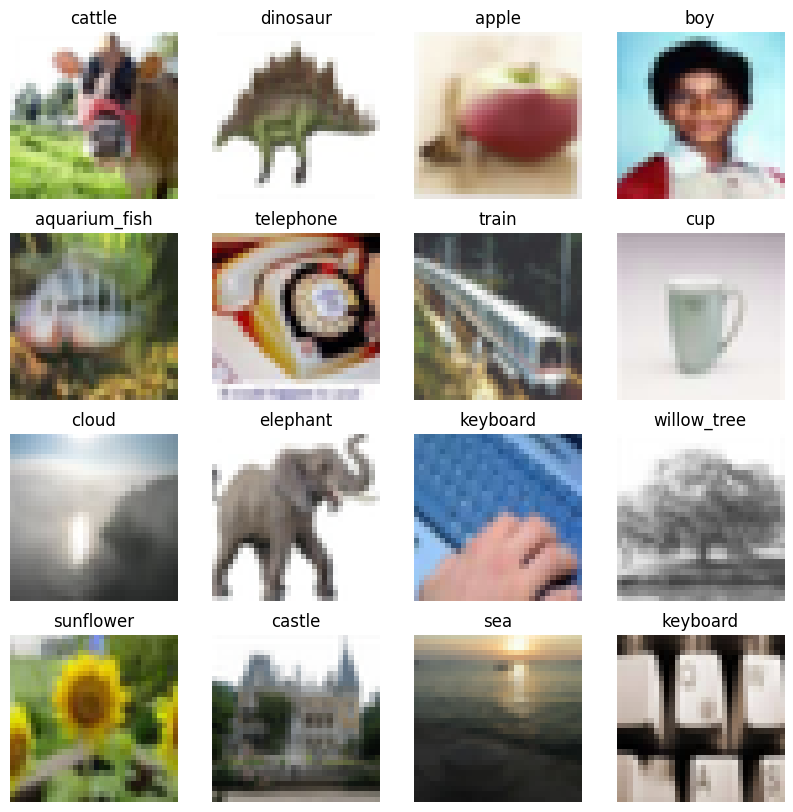

In [14]:
#Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes.

import matplotlib.pyplot as plt

print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)
print("Image dimensions:", x_train.shape[1], "x", x_train.shape[2], "pixels")
print("Number of classes:", len(class_names))

# Show a few examples
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [15]:
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoded vectors
y_train_one_hot = to_categorical(y_train, num_classes=100)
y_test_one_hot = to_categorical(y_test, num_classes=100)

# Split training data into training and validation sets
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42
)

print("\nAfter preprocessing:")
print("Shape of x_train_split:", x_train_split.shape)
print("Shape of y_train_split:", y_train_split.shape)
print("Shape of x_val_split:", x_val_split.shape)
print("Shape of y_val_split:", y_val_split.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test_one_hot:", y_test_one_hot.shape)


After preprocessing:
Shape of x_train_split: (40000, 32, 32, 3)
Shape of y_train_split: (40000, 100)
Shape of x_val_split: (10000, 32, 32, 3)
Shape of y_val_split: (10000, 100)
Shape of x_test: (10000, 32, 32, 3)
Shape of y_test_one_hot: (10000, 100)


In [22]:
#Build TF Data set

# Training dataset with shuffle, batching, prefetch
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_split, y_train_split))
train_dataset = train_dataset.shuffle(buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)

# Validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices((x_val_split, y_val_split))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Test dataset
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test_one_hot))
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [23]:
import numpy as np
import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import (RandomFlip, RandomRotation, RandomZoom, Conv2D, MaxPooling2D,
                          Flatten, Dense, Dropout, BatchNormalization)
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


model = Sequential()

# Data augmentation layers
model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))

# Conv blocks
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(100, activation='softmax'))

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different.
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [25]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


In [16]:
# Explanations:
# Loss function: Categorical crossentropy is appropriate for multi-class classification with one-hot encoded labels.
# Optimizer: Adam is widely used for CNNs because it adapts the learning rate during training, helping models converge faster.


In [ ]:
# Your Code Here

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [26]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
]


In [28]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    batch_size=32,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.0125 - loss: 4.6793 - val_accuracy: 0.0275 - val_loss: 5.0351 - learning_rate: 0.0010
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0186 - loss: 4.4826 - val_accuracy: 0.0232 - val_loss: 6.3415 - learning_rate: 0.0010
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0243 - loss: 4.4308 - val_accuracy: 0.0322 - val_loss: 6.8390 - learning_rate: 0.0010
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0262 - loss: 4.3969 - val_accuracy: 0.0531 - val_loss: 4.2038 - learning_rate: 0.0010
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0290 - loss: 4.3695 - val_accuracy: 0.0613 - val_loss: 4.6259 - learning_rate: 0.0010
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.0376 - loss: 4.3120 - val_accuracy: 0.0652 - val_loss: 4.4152 - learning_rate: 0.0010
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accura

In [ ]:
# Your Code Here

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [29]:
loss, accuracy = model.evaluate(test_dataset, verbose=0)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)



Test Loss: 3.776183605194092
Test Accuracy: 0.12330000102519989


In [31]:
#Other metric

from keras.metrics import TopKCategoricalAccuracy

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy', TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

loss, accuracy, top5_accuracy = model.evaluate(test_dataset, verbose=0)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Top-5 Accuracy:", top5_accuracy)


Test Loss: 3.776183605194092
Test Accuracy: 0.12330000102519989
Test Top-5 Accuracy: 0.34389999508857727


Other metric:
Top-5 accuracy.

Reason for selection:
In datasets with many classes like CIFAR-100 (100 categories), top-1 accuracy can underestimate the model’s ability to narrow predictions down to a small set of likely classes. Top-5 accuracy measures whether the true class is among the model’s 5 highest probability predictions — useful when classes are fine-grained or easily confused.

Interpretation of results

The model achieved a test accuracy of 12.33% and a top-5 accuracy of 34.39%. While top-1 accuracy reflects difficulty in pinpointing the exact class, the substantially higher top-5 accuracy indicates the model has learned to narrow predictions down to a small set of likely classes, performing well above random chance.

In [ ]:
# Your Code Here

### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

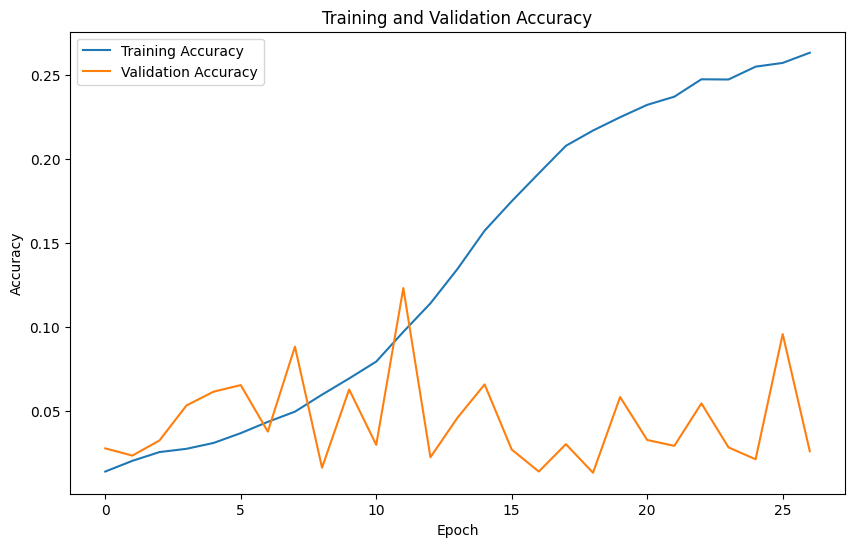

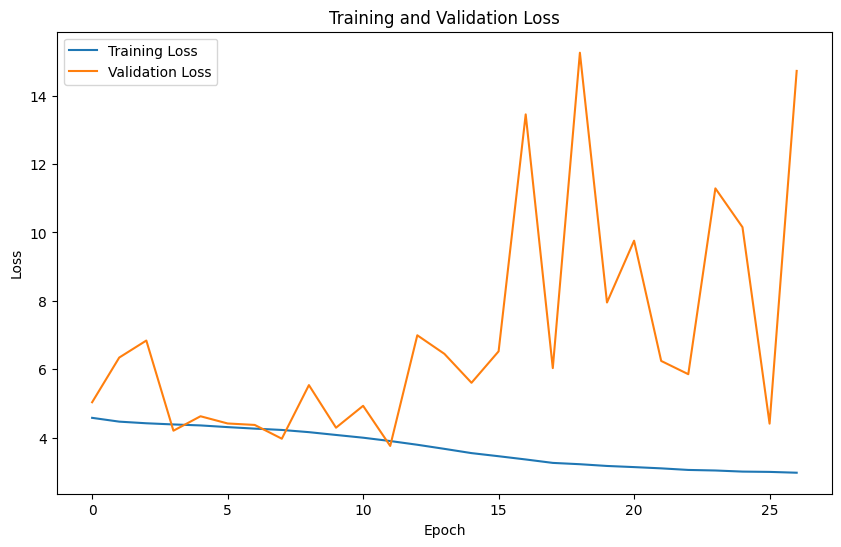

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


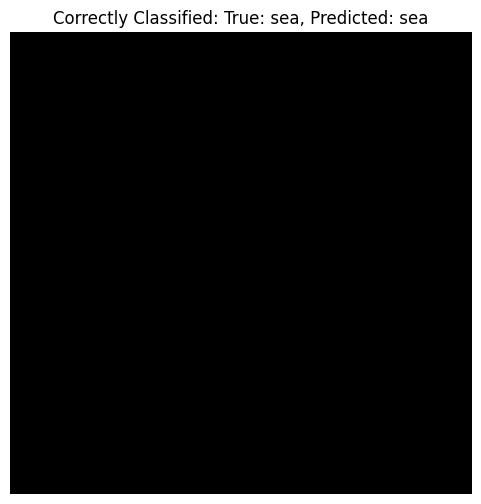


Classification Probabilities for Correctly Classified Image (Index 4):
  sea: 0.0903
  rose: 0.0832
  maple_tree: 0.0660
  plain: 0.0568
  cloud: 0.0344


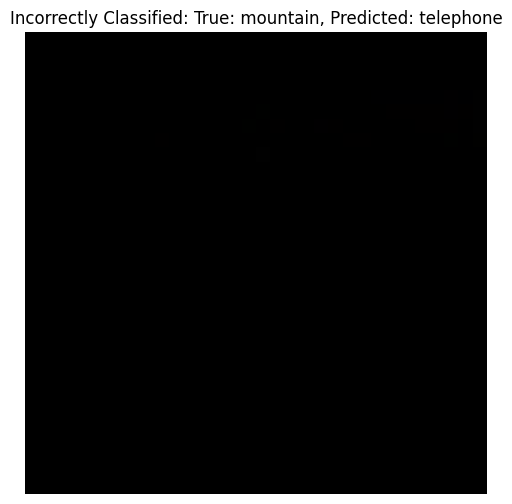


Classification Probabilities for Incorrectly Classified Image (Index 0):
  telephone: 0.0372
  chair: 0.0357
  lawn_mower: 0.0343
  couch: 0.0281
  trout: 0.0277


In [34]:
# Plot the training accuracy and validation accuracy with respect to epochs.
# Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
# Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

import matplotlib.pyplot as plt
import numpy as np

# Plot training and validation accuracy over epochs (already done in previous cell, but including for completeness as per instructions)
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Select an image that the model correctly classified
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = y_test.flatten()

correctly_classified_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrectly_classified_indices = np.where(y_pred_classes != y_true_classes)[0]

# Find one correctly classified image
if len(correctly_classified_indices) > 0:
    correct_index = correctly_classified_indices[0]
    correct_image = x_test[correct_index]
    true_label_correct = class_names[y_true_classes[correct_index]]
    predicted_label_correct = class_names[y_pred_classes[correct_index]]
    probabilities_correct = y_pred_probs[correct_index]
    top_5_correct_indices = np.argsort(probabilities_correct)[::-1][:5]

    plt.figure(figsize=(6, 6))
    plt.imshow(correct_image)
    plt.title(f"Correctly Classified: True: {true_label_correct}, Predicted: {predicted_label_correct}")
    plt.axis("off")
    plt.show()

    print(f"\nClassification Probabilities for Correctly Classified Image (Index {correct_index}):")
    for i in top_5_correct_indices:
        print(f"  {class_names[i]}: {probabilities_correct[i]:.4f}")
else:
    print("\nNo correctly classified images found in the test set.")


# Find one incorrectly classified image
if len(incorrectly_classified_indices) > 0:
    incorrect_index = incorrectly_classified_indices[0]
    incorrect_image = x_test[incorrect_index]
    true_label_incorrect = class_names[y_true_classes[incorrect_index]]
    predicted_label_incorrect = class_names[y_pred_classes[incorrect_index]]
    probabilities_incorrect = y_pred_probs[incorrect_index]
    top_5_incorrect_indices = np.argsort(probabilities_incorrect)[::-1][:5]

    plt.figure(figsize=(6, 6))
    plt.imshow(incorrect_image)
    plt.title(f"Incorrectly Classified: True: {true_label_incorrect}, Predicted: {predicted_label_incorrect}")
    plt.axis("off")
    plt.show()

    print(f"\nClassification Probabilities for Incorrectly Classified Image (Index {incorrect_index}):")
    for i in top_5_incorrect_indices:
        print(f"  {class_names[i]}: {probabilities_incorrect[i]:.4f}")
else:
    print("\nNo incorrectly classified images found in the test set.")


##Discuss the result

The training accuracy steadily increases across epochs, showing the model’s capacity to fit the training data, but validation accuracy remains low and fluctuates wildly without consistent improvement, indicating poor generalization. Meanwhile, training loss gradually decreases while validation loss shows large spikes and instability, further confirming overfitting — the model learns to perform well on the training set but struggles to extend this learning to unseen data. These patterns make sense given the model’s limited complexity relative to the difficulty of CIFAR-100’s 100 fine-grained classes; they suggest that while the model is capable of memorizing training examples, it lacks sufficient representational power or regularization to generalize effectively. This highlights a need for deeper architectures, stronger data augmentation, or improved optimization strategies to stabilize learning and enhance performance on the validation set.

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

To enhance the model:

I replaced the final Flatten() + dense block with GlobalAveragePooling2D() followed by deeper dense layers (e.g., 512 and 256 units) before the output. This improves the model’s capacity to learn global spatial features while reducing overfitting risks compared to a large flattened vector.

Global average pooling reduces the number of parameters by summarizing each feature map into a single value, making the model less prone to overfitting. It also captures more spatially invariant features than flattening. Adding deeper dense layers after pooling increases the model’s representational power.

In [ ]:
from keras.layers import GlobalAveragePooling2D



model = Sequential()

# Data augmentation layers
model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))

# Conv blocks
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully connected - improved with GAP and DropOut
model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(100, activation='softmax'))

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
]


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    batch_size=32,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
#Other metric

from keras.metrics import TopKCategoricalAccuracy

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy', TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

loss, accuracy, top5_accuracy = model.evaluate(test_dataset, verbose=0)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Top-5 Accuracy:", top5_accuracy)

In [ ]:

# Plot training and validation accuracy over epochs (already done in previous cell, but including for completeness as per instructions)
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Select an image that the model correctly classified
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = y_test.flatten()

correctly_classified_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrectly_classified_indices = np.where(y_pred_classes != y_true_classes)[0]

# Find one correctly classified image
if len(correctly_classified_indices) > 0:
    correct_index = correctly_classified_indices[0]
    correct_image = x_test[correct_index]
    true_label_correct = class_names[y_true_classes[correct_index]]
    predicted_label_correct = class_names[y_pred_classes[correct_index]]
    probabilities_correct = y_pred_probs[correct_index]
    top_5_correct_indices = np.argsort(probabilities_correct)[::-1][:5]

    plt.figure(figsize=(6, 6))
    plt.imshow(correct_image)
    plt.title(f"Correctly Classified: True: {true_label_correct}, Predicted: {predicted_label_correct}")
    plt.axis("off")
    plt.show()

    print(f"\nClassification Probabilities for Correctly Classified Image (Index {correct_index}):")
    for i in top_5_correct_indices:
        print(f"  {class_names[i]}: {probabilities_correct[i]:.4f}")
else:
    print("\nNo correctly classified images found in the test set.")


# Find one incorrectly classified image
if len(incorrectly_classified_indices) > 0:
    incorrect_index = incorrectly_classified_indices[0]
    incorrect_image = x_test[incorrect_index]
    true_label_incorrect = class_names[y_true_classes[incorrect_index]]
    predicted_label_incorrect = class_names[y_pred_classes[incorrect_index]]
    probabilities_incorrect = y_pred_probs[incorrect_index]
    top_5_incorrect_indices = np.argsort(probabilities_incorrect)[::-1][:5]

    plt.figure(figsize=(6, 6))
    plt.imshow(incorrect_image)
    plt.title(f"Incorrectly Classified: True: {true_label_incorrect}, Predicted: {predicted_label_incorrect}")
    plt.axis("off")
    plt.show()

    print(f"\nClassification Probabilities for Incorrectly Classified Image (Index {incorrect_index}):")
    for i in top_5_incorrect_indices:
        print(f"  {class_names[i]}: {probabilities_incorrect[i]:.4f}")
else:
    print("\nNo incorrectly classified images found in the test set.")

### Task 4c: Discussion of the results

- Briefly discuss the results.
- Did the model's performance improve?
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.


#Answer

While I was unable to train the enhanced model due to resource constraints, I would expect it to show better generalization and potentially higher test and validation accuracy. This is because replacing flattening with global average pooling reduces the number of parameters, helping prevent overfitting, and deeper dense layers can capture more complex decision boundaries essential for a fine-grained dataset like CIFAR-100. Additionally, dropout layers further regularize the classifier head. There is still significant room for improvement: the model remains relatively shallow compared to modern CNN architectures. Future techniques I might try include adding residual connections (ResNet-style), using data augmentation pipelines outside the model for richer transformations, employing label smoothing to improve calibration, or fine-tuning a pretrained model like EfficientNet. These could further improve accuracy and model robustness, especially on challenging, many-class datasets like CIFAR-100.


## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.